# MODEL_OPTIMAL-PORTFOLIO(S1)

These project is about a model that determinate the optimal weights for a portfolio based of the stocks that you gave it.
The strategy is simple: Using "Sequential Least Squares Programming" (SLSQP) I look for a vector of weights "w" that has the minimun negative sharpe ratio starting with fives diferent vectors and telling the model to find the optimal vector from each one of the five starts. In other words, I look for the weights of the stocks on the portfolio in fact that the portfolio is the one who has the biggest sharpe ratio.

**MAINLY ISSUES**

1. I haven't done the test of the models with diferent portfolios and that's the final step to validate (for me) these model focused on determinate your optimal portfolio of the stocks you gave it.
2. The stocks that yahoo finance give me are just stocks that actualy exist and have been "alive" since 2010-01-01, In the way that the model is not trained with both stocks "alive" and "death" like if we were using the model in real enviroment.
3. I need to do one final step to validate not the model, but the parameters using in the model like "wd"=378, "rd"=21 and "max_w"=0.5. The way that Im validating this is with "Walk-forward / validation out-of-sample" 

### MODEL SET-UP

Import key liberies to start the project

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf


import warnings
warnings.filterwarnings("ignore", message="Values in x were outside bounds")

Download all the tickets of my current portfolio for the train of the model (and the S&P500 cause it's one bench).


In [13]:
tickers = ["LOPE","MTD","WAT","CPAY","LRCX","NVO","ACN","SNA"]
prices = yf.download(tickers, start = "2011-01-01", end="2026-07-01", auto_adjust=True)["Close"]
sp500 = yf.download("VOO", start="2010-01-01", end="2026-07-01", auto_adjust=True)["Close"]

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed


Use the prices that I downloaded to make a DataFrame of the percent changes of the prices called "df_ret" and do the same with the S&P500

In [14]:
# Define variables
df_ret = pd.DataFrame(prices.pct_change().dropna())
sp500_ret = sp500.pct_change().dropna()
sp500_ret=pd.Series(sp500_ret["VOO"])

### Key Functions

Here there are all the functions that I use for the model: two function that calculates the annual return and volatility of a portfolio, the one that calculates the expected return of teh portfolio, the one that calculates the volatility of one asset and the function that calculates the maximum drawdown (the biggest percent loss) of an asset or a portfolio.

In [15]:
def annualized_ret (df_ret):
    n_periods = df_ret.shape[0]
    compuded_growth = (df_ret+1).prod()
    daily_ret = (compuded_growth+1)**(1 / n_periods)-1
    annualized_ret = (daily_ret+1)**252 -1
    return annualized_ret

In [16]:
def port_exret (df_ret, weights, ann_ret=None):
    if ann_ret is None:
        annualized_ret_values = annualized_ret(df_ret)
        exp_ret = np.dot(annualized_ret_values, weights)
    else:
        exp_ret = np.dot(ann_ret, weights)
    return exp_ret

In [17]:
def ann_vol (asset_ret):
    ann_vol = asset_ret.std() * np.sqrt(252)
    return ann_vol

In [18]:
def port_vol (cov_matrix, weights):
    port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    port_var = max(port_var, 0)   # corrige negativos espurios por error de punto flotante
    port_vol = np.sqrt(port_var)
    return port_vol

In [19]:
def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_dd = drawdown.min()
    return max_dd

### Function to find the "optimal" weights

This is the function were the optimal weigths are calculated, with a default setting of: `'maximum weight per stock=1.0` (100% of the portfolio, no restriction)', `use_shrinkage=True` "use_shrinkage" it's a setting to "regulate" the covariance_matrix by LedoitWolf, it's recomended if your data it's too influenced by the amount of the returns of your assets. Let me put you an example: If a stock goes up 10% in one week (totally possible), when the model calculates the annual return of that stock, will see a 14,197% annualy!
So the LedoitWolf regulates these by calculating a "delta" which is the quantitive way to say how much you data is influnced by the amount of returns and use a formula to make a much-real covariance matrix.

In [20]:
def opt_weights(df_ret, max_weight=1.0, use_shrinkage=True):
    n_assets = df_ret.shape[1]

    if use_shrinkage:
        lw = LedoitWolf()
        lw.fit(df_ret.values)
        cov_mtx = lw.covariance_ * 252
    else:
        cov_mtx = df_ret.cov().values * 252

    max_w = max_weight if max_weight is not None else 1.0

    if max_w * n_assets < 1.0:
        raise ValueError(
            f"max_weight={max_w} es infactible con {n_assets} activos "
            f"(máximo posible: {max_w * n_assets:.2f} < 1.0)"
        )

    def neg_sharpe(w):
        p_ret = port_exret(df_ret, w)
        p_vol = port_vol(cov_mtx, w)
        if p_vol <= 1e-8 or not np.isfinite(p_vol):
            return 1e6 
        val = -p_ret / p_vol
        if not np.isfinite(val):
            return 1e6
        return val

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0, max_w) for _ in range(n_assets)]

    def clip_and_normalize(w):
        w_clipped = np.clip(w, 0, max_w)
        if w_clipped.sum() <= 0:
            return np.ones(n_assets) / n_assets
        return w_clipped / w_clipped.sum()

    np.random.seed(42)
    starting_points = [np.ones(n_assets) / n_assets]
    for _ in range(4):
        w_rand = np.random.random(n_assets)
        w_rand = np.minimum(w_rand, max_w)
        w_rand = w_rand / w_rand.sum()
        starting_points.append(w_rand)

    best_w = np.ones(n_assets) / n_assets
    best_val = neg_sharpe(best_w)

    for w0 in starting_points:
        result = minimize(
            neg_sharpe,
            w0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": 1000, "ftol": 1e-9}
        )

        w_feasible = clip_and_normalize(result.x)
        val = neg_sharpe(w_feasible)

        if val < best_val:
            best_val = val
            best_w = w_feasible

    return best_w

### Backtesting Function

This is the backtest function, it's used to test the model in a "real" enviorment, the default setting are: "wd" `window_days=378`, "rd" `rebalance_days=21`, `max_weight=None`, `commission_rate=0.0025`, `use_shrinkage=True`. I'll explain; The data start in 2010-01-01, then the model wait without making changes to the weights and use the first "wd" (378d) to calculate the optimal weights in {2010-01-01 + 378 days} and change the weights from the original to the optimal for "rd" (21d). After 21 days with the new weights, the model starts again calculating the optimal weights of the last 378 days and changing another time the optimal weights for 21 days and constantly doing the same cycle of operations until the {days used + next "rd" >= total days of returns} in these case, total days of returns ~ 5,660 days (2011-01-01 to 2026-07-01).
At the same time we take a commission of 0.25% for a buy or a sell of any asset, and substract the commission from only the first day of the "rd" that is the first day using the new "portfolio".
Also you can put a restriction of the maximum weight for every asset in the way that the model don't put the 70% of the portfolio in one stock that it's going well for the last 378 days for x or y reason (dificult but possible), but intrinsically it's not creating real value. It's just a matter of diversification.

In [21]:
def frun_backtest(df_ret, window_days=378, rebalance_days=21, max_weight=None, commission_rate=0.0025, 
                  use_shrinkage=True):
    
    np.random.seed(42)
    n_portfolios = 10000
    
    portfolio_returns = []
    dates_used=[]
    weights_history={}
    
    i = window_days
    prev_weights = None
    n_rebalances = 0
    
    while i + rebalance_days <= len(df_ret):
        # training window
        df_window = df_ret.iloc[i - window_days:i]
    
        # Calculate optimal weights for training window
        opt_weights_w = opt_weights (df_window, max_weight=max_weight, use_shrinkage=use_shrinkage)
    
        # Save weights and the dates used
        current_date = df_ret.index[i]
        weights_history[current_date] = dict(zip(df_ret.columns, opt_weights_w))
    
        # Calculate and apply commission to the rebalance
        if prev_weights is None:
            turnover = np.sum(np.abs(opt_weights_w))
        else:
            turnover = np.sum(np.abs(opt_weights_w - prev_weights))
    
        commission_cost = turnover * commission_rate
    
        # Apply those weights for the next two months
        df_next = df_ret.iloc[i:i + rebalance_days]
        daily_ret = (df_next * opt_weights_w).sum(axis=1)
    
        # Substract the commission only the first day of the window
        daily_ret_list = daily_ret.values.copy()
        daily_ret_list[0] = daily_ret_list[0] - commission_cost
    
        # Calculate the portfolios returns
        portfolio_returns.extend(daily_ret_list)
        dates_used.extend(df_next.index)
    
        prev_weights = opt_weights_w
        i+=rebalance_days
        n_rebalances += 1
    
    portfolio_series = pd.Series(portfolio_returns, index=dates_used)
    cumulative_rolling = (1+portfolio_series).cumprod()
    total_port_ret = (1+portfolio_series).prod()
    ann_port_ret = annualized_ret (portfolio_series)
    ann_port_vol = ann_vol (portfolio_series)
    port_sharpe = ann_port_ret/ann_port_vol
    port_max_dd = max_drawdown(cumulative_rolling)
    

    return {"window_days":window_days,
            "rebalance_days":rebalance_days,
            "max_weight":max_weight,
            "use_shrinkage": use_shrinkage,
            "total_ret":total_port_ret,
            "ann_ret":ann_port_ret,
            "ann_vol":ann_port_vol,
            "sharpe": port_sharpe,
            "max_dd": port_max_dd,
            "n_rebalances":n_rebalances,
            "portfolio_series":portfolio_series,
            "weights_history":weights_history,
            "dates_used":dates_used
           }

### Finding the "optimal_parameters"

Here I used all the things already explained to find the best values of the parameters in the "opt_weights" and "frun_backtest" functions.
And I did a lot of comparations of diferents "wd" with "rd", also I compared diferent "max_weight", "use_shrinkage"= {True or False} and more.

In [22]:
res2_v2=[]
for wd in [126, 252, 378, 504, 630]:
    for rd in [21, 42, 84, 126]:
        res=frun_backtest(df_ret, wd, rd, commission_rate=0.0025)

        if res:
            res2_v2.append(res)
            
summary2_v2=pd.DataFrame(res2_v2).drop(columns=["n_rebalances","portfolio_series","weights_history","dates_used"])
print(summary2_v2.sort_values("sharpe", ascending=False).head(10))

    window_days  rebalance_days max_weight  use_shrinkage  total_ret  \
10          378              84       None           True  15.295070   
9           378              42       None           True  15.126493   
7           252             126       None           True  15.422798   
11          378             126       None           True  14.214890   
8           378              21       None           True  14.407502   
6           252              84       None           True  15.483766   
5           252              42       None           True  14.668518   
4           252              21       None           True  14.242454   
12          504              21       None           True  10.569867   
13          504              42       None           True  10.105828   

     ann_ret   ann_vol    sharpe    max_dd  
10  0.226555  0.193911  1.168348 -0.311906  
9   0.222622  0.195091  1.141116 -0.309089  
7   0.221287  0.196127  1.128282 -0.338318  
11  0.223420  0.198282  1.1

In [23]:
res2_v3=[]
for max_wgh in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1]:
    res = frun_backtest(df_ret, window_days=378, rebalance_days=21, max_weight=max_wgh, commission_rate=0.0025)

    if res:
        res2_v3.append(res)
summary2_v3=pd.DataFrame(res2_v3).drop(columns=["n_rebalances","portfolio_series","weights_history","dates_used"])
print(summary2_v3.sort_values("sharpe", ascending=False).head(10))

   window_days  rebalance_days  max_weight  use_shrinkage  total_ret  \
3          378              21         0.5           True  14.766845   
2          378              21         0.4           True  14.735704   
4          378              21         0.6           True  14.516189   
5          378              21         0.7           True  14.439008   
6          378              21         1.0           True  14.407502   
1          378              21         0.3           True  13.126730   
0          378              21         0.2           True  11.505338   

    ann_ret   ann_vol    sharpe    max_dd  
3  0.219173  0.195369  1.121844 -0.313416  
2  0.219000  0.195500  1.120207 -0.313445  
4  0.217770  0.195391  1.114534 -0.313416  
5  0.217334  0.195279  1.112942 -0.313416  
6  0.217155  0.195289  1.111971 -0.313416  
1  0.209589  0.193252  1.084539 -0.313907  
0  0.199039  0.192461  1.034176 -0.327452  


In [25]:
window_days = 378
rebalance_days = 21
commission_rate = 0.0025

# --- Markowitz without shrinkage
res_no_shrink = frun_backtest(df_ret, window_days=window_days, rebalance_days=rebalance_days,
                                max_weight=0.5, commission_rate=commission_rate, use_shrinkage=False)

# --- Markowitz with shrinkage
res_shrink = frun_backtest(df_ret, window_days=window_days, rebalance_days=rebalance_days,
                             max_weight=0.5, commission_rate=commission_rate, use_shrinkage=True)

dates_used = res_shrink["dates_used"]
# --- Portfolio 1/N (bench)
equal_weights = np.ones(df_ret.shape[1]) / df_ret.shape[1]
bench_series = ((df_ret.loc[dates_used] * equal_weights).sum(axis=1))
ann_bench_ret = annualized_ret(bench_series)
ann_bench_vol = ann_vol(bench_series)
bench_sharpe = ann_bench_ret / ann_bench_vol

print("=== Comparation ===")
print(f"Markowitz without shrinkage   -> Sharpe: {res_no_shrink['sharpe']:.4f}, ann_ret: {res_no_shrink['ann_ret']:.4f}, ann_vol: {res_no_shrink['ann_vol']:.4f}, max_dd: {res_no_shrink['max_dd']:.4f}")
print(f"Markowitz with shrinkage   -> Sharpe: {res_shrink['sharpe']:.4f}, ann_ret: {res_shrink['ann_ret']:.4f}, ann_vol: {res_shrink['ann_vol']:.4f}, max_dd: {res_shrink['max_dd']:.4f}")
print(f"1/N (equal-weight)        -> Sharpe: {bench_sharpe:.4f}, ann_ret: {ann_bench_ret:.4f}, ann_vol: {ann_bench_vol:.4f}")

=== Comparation ===
Markowitz without shrinkage   -> Sharpe: 1.1267, ann_ret: 0.2201, ann_vol: 0.1953, max_dd: -0.3146
Markowitz with shrinkage   -> Sharpe: 1.1218, ann_ret: 0.2192, ann_vol: 0.1954, max_dd: -0.3134
1/N (equal-weight)        -> Sharpe: 1.0360, ann_ret: 0.2051, ann_vol: 0.1979


In [28]:
lw_check = LedoitWolf()
lw_check.fit(df_ret.iloc[0:window_days].dropna(how="any").values)
print(f"Delta of shrinkage (example window): {lw_check.shrinkage_:.4f}")

Delta of shrinkage (example window): 0.0260


In [29]:
window_days_short = 63
rebalance_days = 21

res2_no_shrink = frun_backtest(df_ret, window_days=window_days_short, rebalance_days=rebalance_days,
                                  max_weight=None, commission_rate=commission_rate, use_shrinkage=False)
res2_shrink = frun_backtest(df_ret, window_days=window_days_short, rebalance_days=rebalance_days,
                               max_weight=None, commission_rate=commission_rate, use_shrinkage=True)

print("=== Comparation ===")
print(f"Markowitz without shrinkage   -> Sharpe: {res2_no_shrink['sharpe']:.4f}, ann_ret: {res2_no_shrink['ann_ret']:.4f}, ann_vol: {res2_no_shrink['ann_vol']:.4f}, max_dd: {res2_no_shrink['max_dd']:.4f}")
print(f"Markowitz with shrinkage   -> Sharpe: {res2_shrink['sharpe']:.4f}, ann_ret: {res2_shrink['ann_ret']:.4f}, ann_vol: {res2_shrink['ann_vol']:.4f}, max_dd: {res2_shrink['max_dd']:.4f}")

lw2_check = LedoitWolf()
lw2_check.fit(df_ret.iloc[0:window_days_short].dropna(how="any").values)
print(f"Delta of shrinkage (window of {window_days_short} days): {lw2_check.shrinkage_:.4f}")

=== Comparation ===
Markowitz without shrinkage   -> Sharpe: 0.6953, ann_ret: 0.1382, ann_vol: 0.1987, max_dd: -0.3523
Markowitz with shrinkage   -> Sharpe: 0.7441, ann_ret: 0.1466, ann_vol: 0.1970, max_dd: -0.3441
Delta of shrinkage (window of 63 days): 0.1677


### Graphics and conclusions

Here don't put attention to the codes, just in the graphics and tables of results.
You will see a comparation with the principal bench (the portfolio without the weights-optimisation) and one second bench that is the S&P500.
And in the bottom there is a graphic of the weights changes, so you can apreciate how the weight of one stock is moving at the pass of the years.

In [30]:
opt_portfolio=frun_backtest(df_ret, window_days=378, rebalance_days=21, max_weight=0.5, commission_rate=0.0025, use_shrinkage=False)
opt_ann_ret = opt_portfolio["ann_ret"]
opt_ann_vol = opt_portfolio["ann_vol"]
opt_sharpe = opt_portfolio["sharpe"]
opt_max_dd = opt_portfolio["max_dd"]
opt_port_series = opt_portfolio["portfolio_series"]
opt_port_cumultive = (1+opt_port_series).cumprod()

In [31]:
dates_used = opt_portfolio["dates_used"]
equal_weights = np.ones(df_ret.shape[1])/df_ret.shape[1]
bench_series = ((df_ret.loc[dates_used] * equal_weights).sum(axis=1))
cumulative_bench = (1 + (df_ret.loc[dates_used] * equal_weights).sum(axis=1)).cumprod()
cumulative_sp500 = (sp500_ret.loc[dates_used] + 1).cumprod()

ann_bench_ret = annualized_ret(bench_series)
ann_bench_vol = ann_vol(bench_series)
bench_sharpe = ann_bench_ret/ann_bench_vol
bench_max_dd = max_drawdown(cumulative_bench)

ann_sp500_ret = annualized_ret (sp500_ret)
sp500_ann_vol = ann_vol(sp500_ret)
sp500_sharpe = ann_sp500_ret/sp500_ann_vol
sp500_max_dd = max_drawdown(cumulative_sp500)

In [32]:
print(f"opt_portfolio: ann_ret: {opt_ann_ret:.2%}, ann_vol: {opt_ann_vol:.2%}, sharpe: {opt_sharpe:.4f}, max_dd: {opt_max_dd:.2%}")
print(f"bench: ann_ret: {ann_bench_ret:.2%}, ann_vol: {ann_bench_vol:.2%}, sharpe: {bench_sharpe:.4f}, max_dd: {bench_max_dd:.2%}")
print(f"S&P500: ann_ret: {ann_sp500_ret:.2%}, ann_vol: {sp500_ann_vol:.2%}, sharpe: {sp500_sharpe:.4f}, max_dd: {sp500_max_dd:.2%}")

opt_portfolio: ann_ret: 22.01%, ann_vol: 19.53%, sharpe: 1.1267, max_dd: -31.46%
bench: ann_ret: 20.51%, ann_vol: 19.79%, sharpe: 1.0360, max_dd: -34.05%
S&P500: ann_ret: 15.72%, ann_vol: 17.04%, sharpe: 0.9227, max_dd: -33.99%


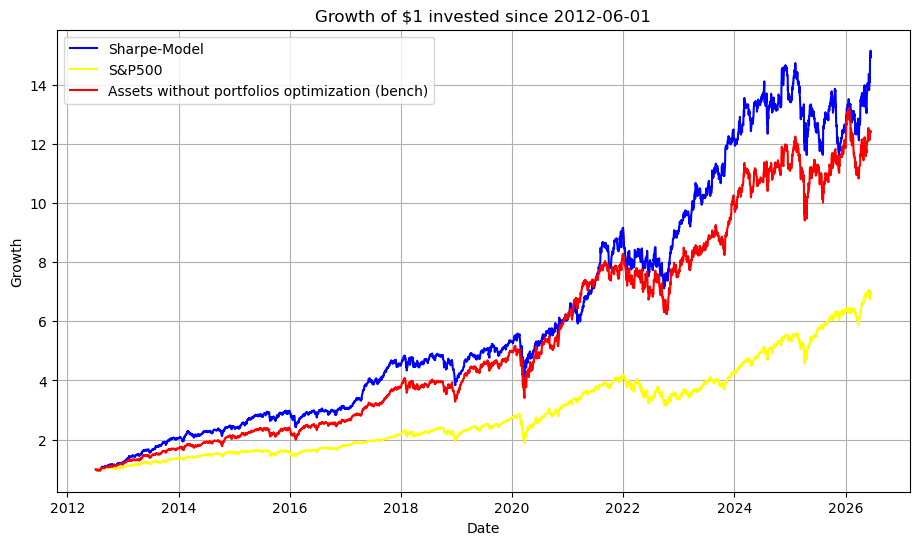

In [33]:
plt.figure(figsize=(11,6))
plt.plot(opt_port_cumultive, label="Sharpe-Model", color="Blue")
plt.plot(cumulative_sp500, label="S&P500", color="Yellow")
plt.plot(cumulative_bench, label="Assets without portfolios optimization (bench)", color="Red")
plt.title("Growth of $1 invested since 2012-06-01")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.grid(True)
plt.show()

**Conclusión**
| | Modelo-Sharpe |Bench| S&P 500 (VOO) |
|---|---|---|---|
| Retorno anualizado | 22.01% | 20.51% | 15.07% |
| Volatilidad anualizada | 19.53% | 19.79% | 17.11% |
| Sharpe ratio | 1.127 | 1.036 | 0.881 |
| Max drawdown | -31.46% | -34.05% | -33.99% |

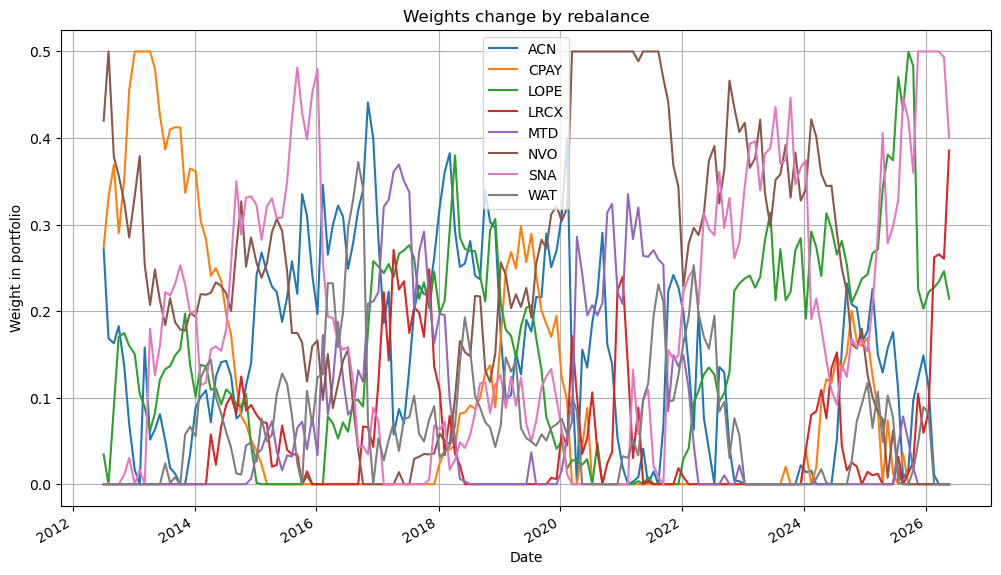

In [34]:
weights_history = opt_portfolio["weights_history"]
df_weights_history = pd.DataFrame(weights_history).T
df_weights_history.plot(figsize=(12,7), title="Weights change by rebalance")
plt.ylabel("Weight in portfolio")
plt.xlabel("Date")
plt.legend(loc="best")
plt.grid(True)
plt.show()